# Graphe Hydrographique

## Import des librairies

In [72]:
import pathlib
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import pyproj
import networkx as nx
from shapely import Point, LineString, MultiLineString, GeometryCollection, STRtree
from shapely.ops import split, snap, linemerge, unary_union
from tqdm.auto import tqdm
from shapely import box
import shapely
import pickle
from collections import deque
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import requests

# I. Premiers essais de tracés

### 1. Prétraitement des données

On commence par travailler avec trois bases de données : les cours d'eau, les tronçons hydrographiques, et les sites (qui correspondent aux stations de relevé de températures).

In [7]:
# Code OH de la Seine
Code_OH = "03C00000020008"

# Geofframe des cours d'eau et prétraitement pour ne récupérer que la Seine
gdf_ce = gpd.read_file("données hackaton/CoursEau/CoursEau_FXX.shp")

m = gdf_ce['CdOH'].str.startswith(Code_OH)
seine_ce = gdf_ce[m].copy()


# Geoframe des tronçons hydrographiques et prétraitement
bbox = box(490000, 6658000, 861000, 6981000)
gdf_tr = gpd.read_file(
    "données hackaton/TronconHydrographique/TronconHydrographique_FXX.shp",
    bbox=bbox,
).set_index("CdOH")

patch = {
    "03T0000002287758528": {"TopoOH": "la Marne", "CdCoursEau": "03C0000002000815787"},
    "03T0000002287758537": {"TopoOH": "la Marne", "CdCoursEau": "03C0000002000815787"},
}

gdf_tr.update(pd.DataFrame.from_dict(patch, orient="index"))

m = gdf_tr['CdCoursEau'].fillna("").str.startswith(Code_OH)
seinetr = gdf_tr[m].copy()
seinetr["geometry"] = seinetr.force_2d()

# Geoframe des stations
sites = gpd.read_file("données hackaton/Sites/Sites.shp")

# Station à l'estuaire
root_node = sites.loc[sites["Libellé"] == "Balise fond", "geometry"]
root_node = root_node.squeeze().coords[0]

### 2. Graphe construit avec les cours d'eau uniquement

In [8]:
seine_ce1 = seine_ce.explode(ignore_index = True)
sites_ce1 = sites[~sites.is_empty]

# récupération des indices des lignstrings les plus proches de chaque station (nos sites)
# pos1 sont nos indices des stations, pos2 les lignstrings.
pos1, pos2 = seine_ce1.sindex.nearest(sites_ce1["geometry"], return_all = False) 

In [9]:
for idx1, idx2 in zip(pos1, pos2):
    pt = sites_ce1.loc[idx1, "geometry"]
    ls = seine_ce1.loc[idx2, "geometry"]

    proj_pt = ls.interpolate(ls.project(pt)) # projection du point sur la ls pour gérer les décalage, puis ajout du point sur la ls.
    snap_ls = snap(ls, proj_pt, tolerance=0.0001) # on rajoute une brisure à la ligne, pour qu'un nouveau segment brisé dans la ligne ait pour bout la station
    split_ls = split(snap_ls, proj_pt) # on split la ligne en deux à l'endroit de la station
    split_ls = linemerge(split_ls) # on merge les lignes pour que ce soit un multilinestring

    sites_ce1.loc[idx1, "geometry"] = proj_pt # on actualise les coordonnées de la station pour que ça soit dans la ligne
    seine_ce1.loc[idx2, "geometry"] = split_ls # on actualise la ligne pour qu'elle soit brisée à l'endroit de la station

In [10]:
topo = seine_ce1.loc[seine_ce1.index[pos2], "TopoOH"].drop_duplicates().to_list()

seine2 = seine_ce1[seine_ce1["TopoOH"].isin(topo)] # on récupère uniquement la seine et ses affluents où on a des stations

In [11]:
G = nx.Graph()

for _, row in tqdm(seine2.iterrows(), total = len(seine2)):
    geom = row.geometry
    for i, j in zip(geom.coords, geom.coords[1:]):
        G.add_edge(i,j, weight = LineString([i,j]).length)

  0%|          | 0/962 [00:00<?, ?it/s]

In [12]:
station_nodes = []
for station in sites_ce1.itertuples(): #itertuples() parcourt les lignes d'un df en leur attribuant un nom
    coord = station.geometry.coords[0] 
    attrs = G.nodes[coord] # vue sur les attributs du noeud lié à la station
    attrs["site_id"] = station.Index # ajout de l'index de la station aux métadata du noeud
    attrs["label"] = station.Libellé # on ajoute aussi le nom de la station
    station_nodes.append(coord) # on garde en mémoire les coordonnées de chaque station

In [13]:
colors = []
for station in station_nodes:
    attrs = G.nodes[station]
    if nx.has_path(G, root_node, station):
        path = nx.shortest_path(G, root_node, station, weight = "weight") # on check s'il existe un chemin de la station à l'estuaire jusqu'à la station vue (mais c'est là qu'on peut avoir un problème avec les discontinuités de lignes de CoursEau)
        colors.append("green")
    else:
        print(f"Pas de chemin entre {root_node} et {station} ({attrs['label']})")
        colors.append("red")

Pas de chemin entre (491068.6, 6930159.499999998) et (661541.1119831252, 6857321.481027052) (Joinville-le-Pont)
Pas de chemin entre (491068.6, 6930159.499999998) et (665629.9923794899, 6861592.949784888) (Neuilly-sur-Marne)
Pas de chemin entre (491068.6, 6930159.499999998) et (662887.495116159, 6856868.711264841) (Parc St Maur)
Pas de chemin entre (491068.6, 6930159.499999998) et (661102.0269408673, 6855508.921306176) (Créteil)
Pas de chemin entre (491068.6, 6930159.499999998) et (758245.0743124629, 6887120.418139262) (Reuil)
Pas de chemin entre (491068.6, 6930159.499999998) et (664592.3, 6859430.999999999) (Charenton (Bry))
Pas de chemin entre (491068.6, 6930159.499999998) et (709786.1919782581, 6872272.923649836) (La Ferté-sous-Jouarre)
Pas de chemin entre (491068.6, 6930159.499999998) et (790855.5834515196, 6878126.470071503) (Matougues)
Pas de chemin entre (491068.6, 6930159.499999998) et (816785.09571794, 6845712.269248725) (Frignicourt)
Pas de chemin entre (491068.6, 6930159.4999

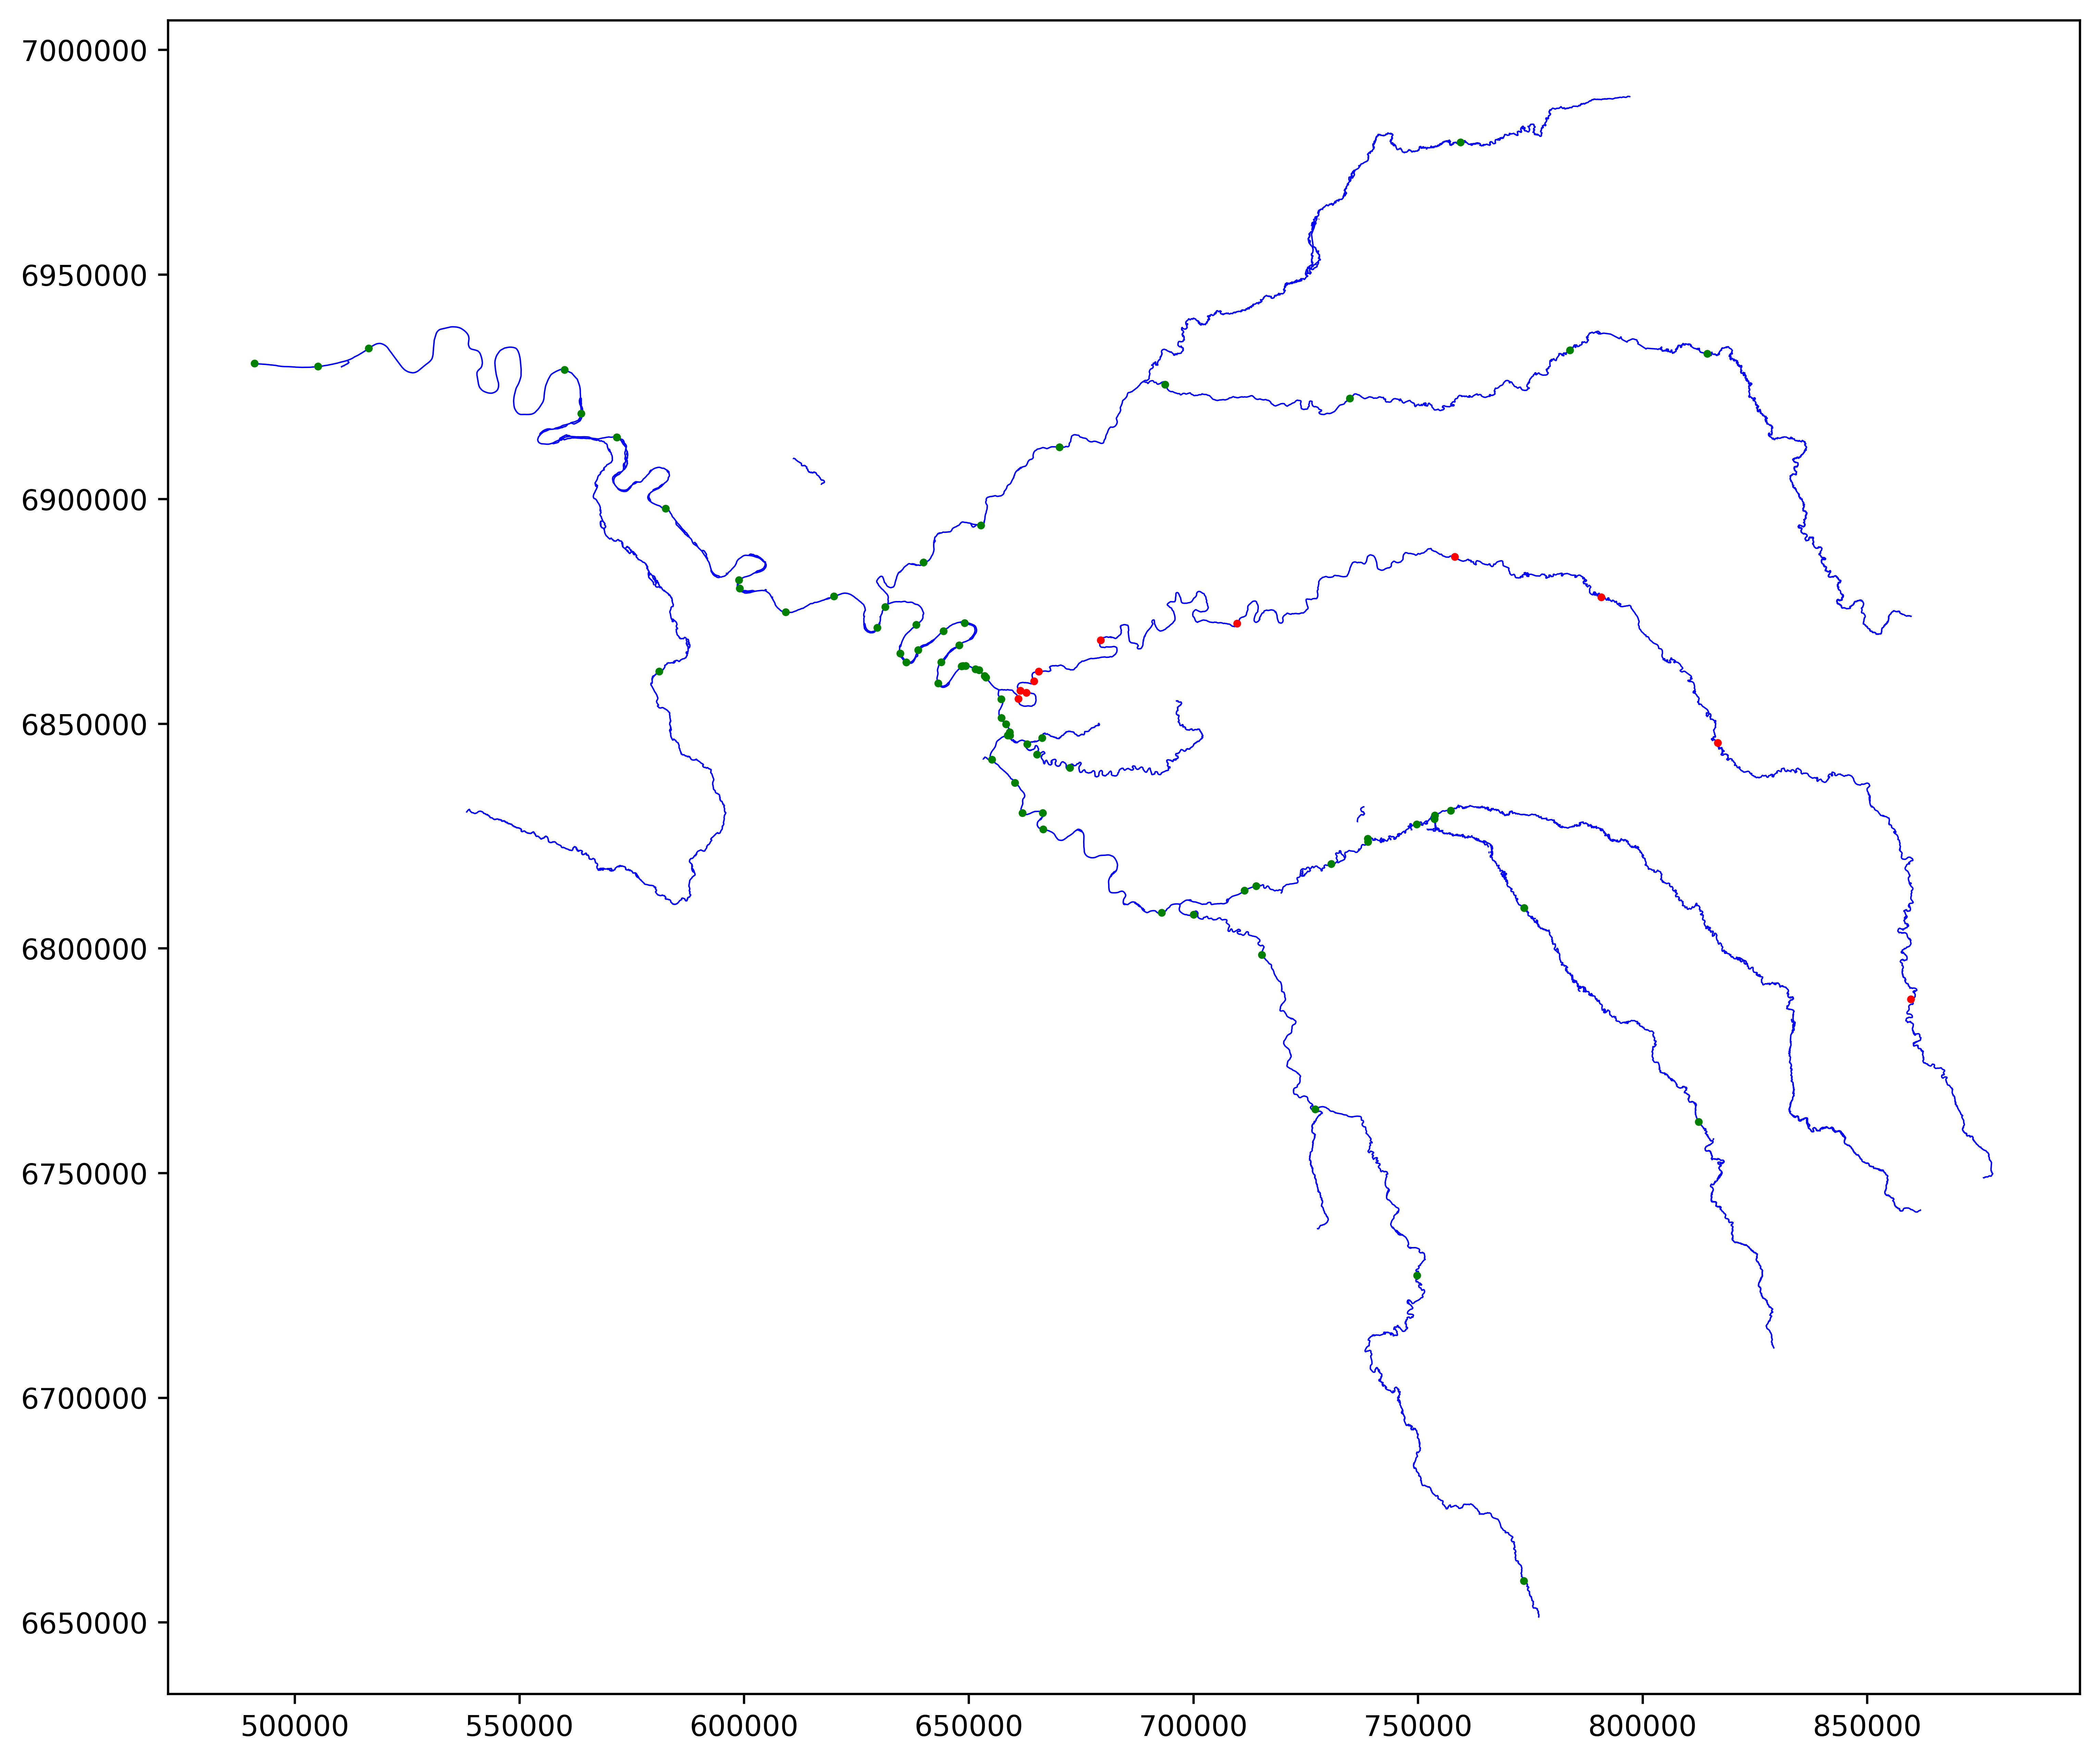

In [14]:
fig, ax = plt.subplots(figsize = (12,12), dpi = 600)
seine2.plot(ax = ax, lw = 0.5, color = "blue", zorder = -1)
sites_ce1.plot(ax = ax, lw = 0.5,color = colors, markersize = 5)
ax.ticklabel_format(style = 'plain', axis = 'both')
plt.show()

### 3. Graphe construit avec les tronçons hydrographiques uniquement

In [15]:
sites_tr1= sites[~sites.is_empty]

In [16]:
seinetr1 = seinetr.explode(ignore_index = True)

pos1, pos2 = seinetr1.sindex.nearest(sites_tr1["geometry"], return_all = False)

for idx1, idx2 in zip(sites_tr1.index[pos1], seinetr1.index[pos2]):
    pt = sites_tr1.loc[idx1, "geometry"]
    ls = seinetr1.loc[idx2, "geometry"]

    proj_pt = ls.interpolate(ls.project(pt)) 
    snap_ls = snap(ls, proj_pt, tolerance=0.0001) 
    split_ls = split(snap_ls, proj_pt) 
    split_ls = linemerge(split_ls)

    sites_tr1.loc[idx1, "geometry"] = proj_pt 
    seinetr1.loc[idx2, "geometry"] = split_ls

topo = seinetr1.loc[seinetr1.index[pos2], "TopoOH"].drop_duplicates().to_list()
seinetr2 = seinetr1[seinetr1["TopoOH"].isin(topo)]

  0%|          | 0/7157 [00:00<?, ?it/s]

Pas de chemin entre (491068.6, 6930159.499999998) et (759526.6470171005, 6979373.1211244585) (Erloy)
Pas de chemin entre (491068.6, 6930159.499999998) et (773615.649664281, 6659173.638854866) (Château-Chinon)
Pas de chemin entre (491068.6, 6930159.499999998) et (749848.9958628722, 6727159.879115539) (Prégilbert)


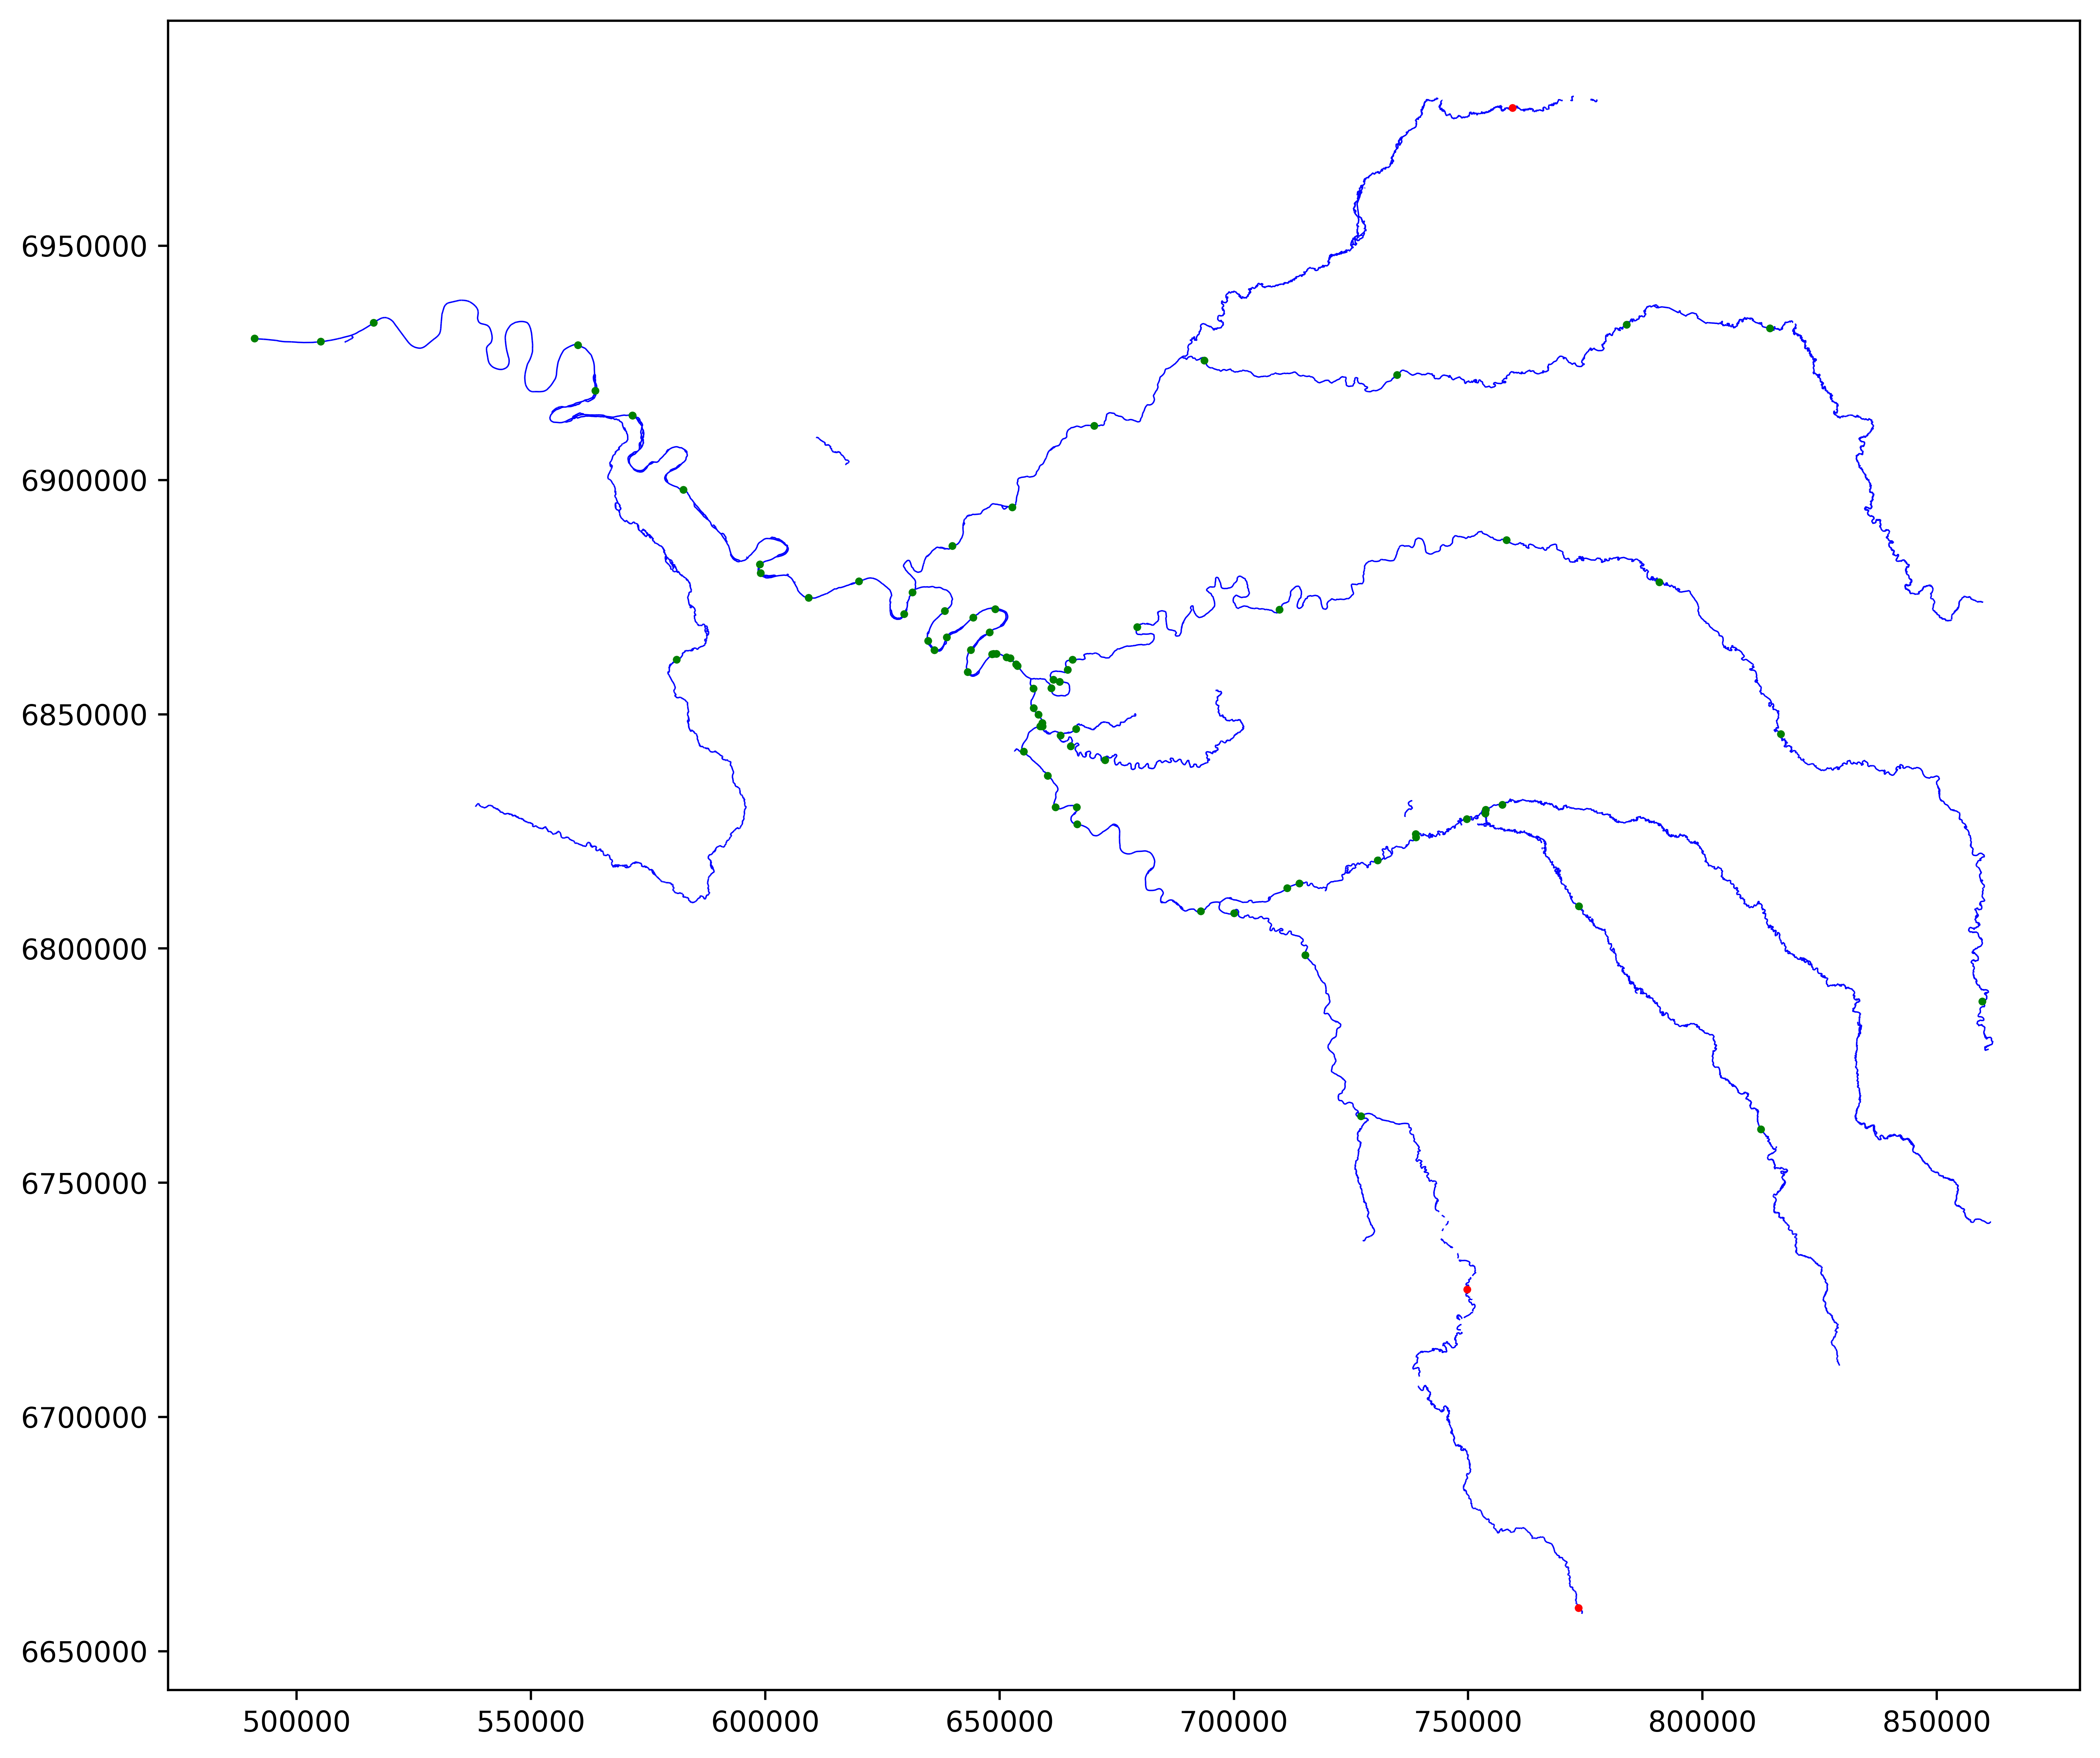

In [17]:
G1 = nx.Graph()

for _, row in tqdm(seinetr2.iterrows(), total = len(seinetr2)): 
    geom = row.geometry
    for i, j in zip(geom.coords, geom.coords[1:]):
        G1.add_edge(i,j, weight = LineString([i,j]).length)

root_node = sites_tr1.loc[sites_tr1["Libellé"] == "Balise fond", "geometry"]
root_node = root_node.squeeze().coords[0]

station_nodes1 = []
for station in sites_tr1.itertuples(): 
    coord = station.geometry.coords[0] 
    attrs = G1.nodes[coord] 
    attrs["site_id"] = station.Index 
    attrs["label"] = station.Libellé 
    station_nodes1.append(coord)

colors1 = []
for station in station_nodes1:
    attrs = G1.nodes[station]
    if nx.has_path(G1, root_node, station):
        path = nx.shortest_path(G1, root_node, station, weight = "weight") # on check s'il existe un chemin de la station à l'estuaire jusqu'à la station vue (mais c'est là qu'on peut avoir un problème avec les discontinuités de lignes de CoursEau)
        colors1.append("green")
    else:
        print(f"Pas de chemin entre {root_node} et {station} ({attrs['label']})")
        colors1.append("red")

fig, ax = plt.subplots(figsize = (12,12), dpi = 600)
seinetr2.plot(ax = ax, lw = 0.5, color = "blue", zorder = -1)
sites_tr1.plot(ax = ax, lw = 0.5,color = colors1, markersize = 5)
ax.ticklabel_format(style = 'plain', axis = 'both')
plt.show()

# II. Contraction du graphe

On implémente une fonction de contraction du graphe pour diminuer sa taille et donc réduire le volume occupé/le temps de traitement, tout en gardant en mémoire les distances réelles associées aux différents cours d'eau.

In [49]:
def contract(g):
    """
    Contract chains of neighbouring vertices with degree 2 into a single edge.

    Arguments:
    ----------
    g -- networkx.Graph or networkx.DiGraph instance

    Returns:
    --------
    h -- networkx.Graph or networkx.DiGraph instance
        the contracted graph
    """

    # Travailler sur la version non orientée pour identifier les chaînes
    ug = g.to_undirected() if g.is_directed() else g

    # Créer le sous-graphe des nœuds de degré 2
    is_chain = [node for node, degree in ug.degree() if ((degree == 2) and (g.nodes[node].get("site_id") is None))]
    chains = ug.subgraph(is_chain)

    # Correction : connected_component_subgraphs supprimé en NX 2.4+
    # On applique connected_components sur chains (pas sur g)
    components = [chains.subgraph(c) for c in nx.connected_components(chains)]

    hyper_edges = []
    for component in components:
        end_points = [node for node, degree in component.degree() if degree < 2]
        candidates = set(neighbor for node in end_points for neighbor in ug.neighbors(node))
        connectors = list(candidates - set(component.nodes()))
        weights = [data.get('weight', 1) for _, _, data in component.edges(data=True)]
        hyper_edges.append((connectors, np.sum(weights)))

    # Initialiser le nouveau graphe sans les nœuds de degré 2
    not_chain = [node for node in g.nodes() if node not in is_chain]
    h = g.subgraph(not_chain).copy()
    for connectors, weight in hyper_edges:
        # Garde-fou : une chaîne en bout de graphe peut avoir < 2 connecteurs
        if len(connectors) == 2:
            h.add_edge(connectors[0], connectors[1], weight=weight)

    return h

# III. Concaténation des db Cours d'eau et tronçons hydrographiques (graphe hydrographique connexe)

But de la section : on voit sur les deux exemples faits précédemment avec la Seine que les stations qui ne sont "pas reliées" à l'estuaire sont différentes selon les df utilisés de base. On va donc considérer que merge les deux dataframes permet de combler les gap.

In [19]:
cours_eau_seine = seine_ce.to_crs(2154)
tronçons_seine = seinetr.to_crs(2154)

In [20]:
noded_geometry = unary_union(list(cours_eau_seine.geometry) + list(tronçons_seine.geometry))

if hasattr(noded_geometry, "geoms"):
    lines_list = list(noded_geometry.geoms)
else:
    lines_list = [noded_geometry]

noded_gdf = gpd.GeoDataFrame(geometry=lines_list, crs=2154)

In [ ]:
noded_gdf['midpoint'] = noded_gdf.geometry.interpolate(0.5, normalized=True)
noded_gdf_pts = noded_gdf.set_geometry('midpoint')

combined_attributes = pd.concat([cours_eau_seine, tronçons_seine], ignore_index=True)

joined = gpd.sjoin_nearest(noded_gdf_pts, combined_attributes, how='left', max_distance=1.0)
joined = joined[~joined.index.duplicated(keep='first')]  # évite les doublons de jointure à distance égale

if 'geometry_left' in joined.columns:
    combined1 = joined.set_geometry('geometry_left').drop(columns=['midpoint', 'geometry_right'])
else:
    combined1 = joined.set_geometry('geometry').drop(columns=['midpoint'])

combined1 = combined1.reset_index(drop=True)
combined1_exp = combined1.explode(ignore_index=True)

La cellule du dessus compile en 14 minutes et quelques, faut juste être TRES patient.e, et par pitié ne pas la relancer.

In [ ]:
pos1, pos2 = combined1_exp.sindex.nearest(sites_tr1["geometry"], return_all=False)

geom_updates = {}
for idx1, idx2 in zip(sites_tr1.index[pos1], combined1_exp.index[pos2]):
    pt = sites_tr1.loc[idx1, "geometry"]
    ls = geom_updates.get(idx2, combined1_exp.loc[idx2, "geometry"])

    proj_pt = ls.interpolate(ls.project(pt))
    snap_ls = snap(ls, proj_pt, tolerance=0.0001)
    split_ls = linemerge(split(snap_ls, proj_pt))

    sites_tr1.loc[idx1, "geometry"] = proj_pt
    geom_updates[idx2] = split_ls

if geom_updates:
    combined1_exp.loc[list(geom_updates.keys()), "geometry"] = list(geom_updates.values())

In [ ]:
topo = combined1_exp.loc[combined1_exp.index[pos2], "TopoOH"].drop_duplicates().to_list()
combined12 = combined1_exp[combined1_exp["TopoOH"].isin(topo)]
combined12.to_file("Graphs/reseau_seine.gpkg", driver="GPKG") # sauvegarde pour les usages futurs

In [ ]:
G2 = nx.Graph()
edges = []

for geom in combined12.geometry.values:
    coords = np.asarray(geom.coords)
    if len(coords) < 2:
        continue
    diffs = coords[1:] - coords[:-1]
    lengths = np.hypot(diffs[:, 0], diffs[:, 1])
    for (x1, y1), (x2, y2), length in zip(coords[:-1], coords[1:], lengths):
        edges.append(((x1, y1), (x2, y2), length))

G2.add_weighted_edges_from(edges)

In [ ]:
root_node = sites_tr1.loc[sites_tr1["Libellé"] == "Balise fond", "geometry"]
root_node = root_node.squeeze().coords[0]

station_nodes2 = []
for station in sites_tr1.itertuples():
    coord = station.geometry.coords[0]
    attrs = G2.nodes[coord]
    attrs["site_id"] = station.Code
    attrs["label"] = station.Libellé
    station_nodes2.append(coord)

In [ ]:
lengths_dij, paths = nx.single_source_dijkstra(G2, root_node, weight="weight")

colors2 = []
for station in station_nodes2:
    attrs = G2.nodes[station]
    if station in paths:
        colors2.append("green")
    else:
        print(f"Pas de chemin entre {root_node} et {station} ({attrs['label']})")
        colors2.append("red")

Sauvegarde du graphe dans un fichier annexe, pour ne pas avoir à recompiler :

In [ ]:
pickle.dump(G2, open('Graphs/G_connexe_non_contracted.pickle', 'wb'))

**Affichage de la version non contractée :**

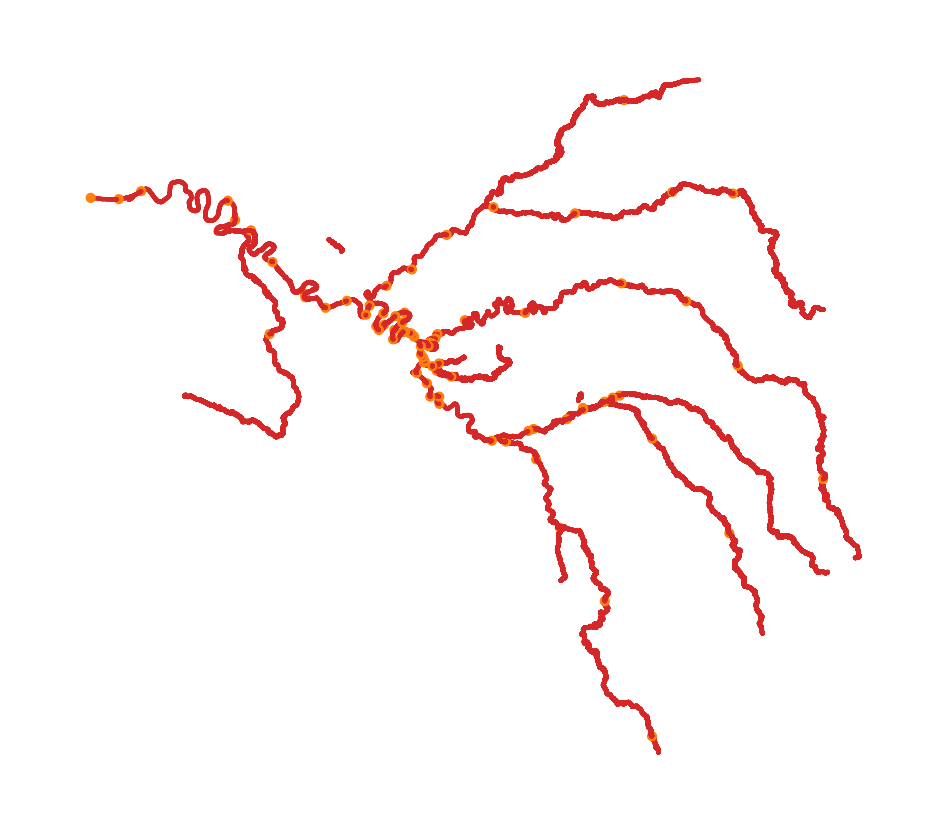

In [ ]:
G = pickle.load(open('Graphs/G_connexe_non_contracted.pickle', 'rb'))

pos_contract = {n: n for n in G.nodes()}

# Couleur différente pour les nœuds correspondant à des stations (sites)
node_colors = [
    "tab:orange" if G.nodes[n].get("site_id") is not None else "tab:red"
    for n in G.nodes()
]
node_sizes = [
    40 if G.nodes[n].get("site_id") is not None else 5
    for n in G.nodes()
]

fig, ax = plt.subplots(figsize=(12, 12))
nx.draw(
    G,
    pos=pos_contract,
    ax=ax,
    node_color=node_colors,
    node_size=node_sizes,
    edge_color="tab:blue",
    width=0.5,
    with_labels=False,
)
ax.set_aspect("equal")
plt.show()

**Sauvegarde et affichage de la version contractée :**

In [ ]:
G2 = pickle.load(open('Graphs/G_connexe_non_contracted.pickle', 'rb'))

G2_contracted = contract(G2)

In [ ]:
pickle.dump(G2_contracted, open('Graphs/G_connexe_contracted.pickle', 'wb'))

In [ ]:
G_contract = pickle.load(open('Graphs/G_connexe_contracted.pickle', 'rb'))

In [54]:
print([(n, G_contract.nodes[n]) for n in G_contract.nodes() if G_contract.nodes[n].get("site_id") is not None])

[((np.float64(631462.799494028), np.float64(6875957.061937694)), {'site_id': '7', 'label': 'Andresy'}), ((np.float64(666622.8358675477), np.float64(6826465.748492188)), {'site_id': '29', 'label': 'Ponthierry Ste Assise'}), ((np.float64(647927.909677202), np.float64(6867427.594518989)), {'site_id': '3', 'label': 'Asnières'}), ((np.float64(759526.6470171005), np.float64(6979373.1211244585)), {'site_id': '63', 'label': 'Erloy'}), ((np.float64(662001.5959641726), np.float64(6830095.7318580095)), {'site_id': '18', 'label': 'Morsang'}), ((np.float64(638366.3364139091), np.float64(6871991.02128288)), {'site_id': '6', 'label': 'Sartrouville'}), ((np.float64(711437.2361380367), np.float64(6812831.41918712)), {'site_id': '47', 'label': 'Balloy'}), ((np.float64(653888.361033366), np.float64(6860259.574811628)), {'site_id': '61', 'label': 'Paris Bercy'}), ((np.float64(783872.8432104122), np.float64(6933097.774099783)), {'site_id': '38', 'label': 'Balham'}), ((np.float64(661541.1119831253), np.floa

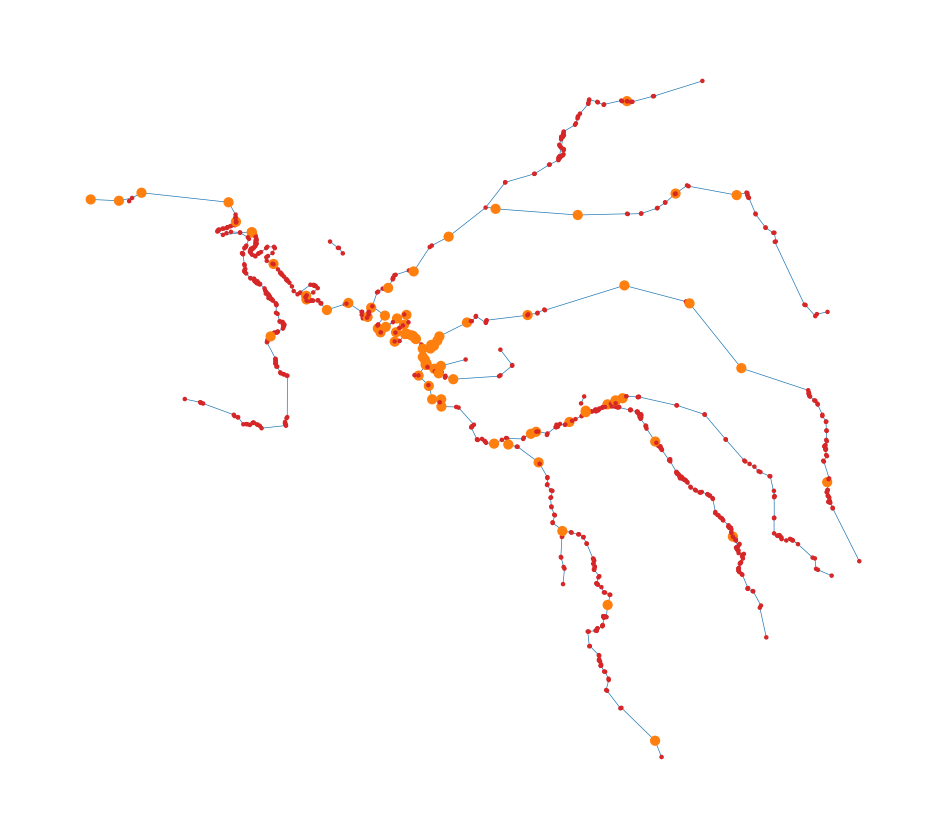

In [ ]:
G_contract = pickle.load(open('Graphs/G_connexe_contracted.pickle', 'rb'))

pos_contract = {n: n for n in G_contract.nodes()}

# Couleur différente pour les nœuds correspondant à des stations (sites)
node_colors = [
    "tab:orange" if G_contract.nodes[n].get("site_id") is not None else "tab:red"
    for n in G_contract.nodes()
]
node_sizes = [
    40 if G_contract.nodes[n].get("site_id") is not None else 5
    for n in G_contract.nodes()
]

fig, ax = plt.subplots(figsize=(12, 12))
nx.draw(
    G_contract,
    pos=pos_contract,
    ax=ax,
    node_color=node_colors,
    node_size=node_sizes,
    edge_color="tab:blue",
    width=0.5,
    with_labels=False,
)
ax.set_aspect("equal")
plt.show()

# IV. Orientation du graphe et prise en compte des distances

Programmation d'une fonction d'orientation du graphe hydrographique, à partir d'un graphe hydrographique CONNEXE non orienté, et de l'exutoire.

In [ ]:
def dfs(graph, node):
    visited = set((node,))
    dg = nx.DiGraph()
    stack = [(node,0.)]
    dg.add_node(node)
    dg.nodes[node]["site_id"]=graph.nodes[node]["site_id"]
    dg.nodes[node]["dist_exut"] = 0.
    while stack:
        node,d = stack[-1]
        if node not in visited:
            visited.add(node)
        remove_from_stack = True
        for next_node,attrs in graph[node].items():
            if next_node not in visited:
                dg.add_edge(next_node,node,weight = attrs['weight'])
                dg.nodes[node]["site_id"] = graph.nodes[node].get("site_id")
                dg.nodes[next_node]["dist_exut"] = d + attrs['weight']
                stack.append((next_node,dg.nodes[node]["dist_exut"]))
                remove_from_stack = False
                break
        if remove_from_stack:
            stack.pop()
    return dg

In [ ]:
G_oriented = dfs(G_contract, root_node)

In [ ]:
pickle.dump(G_oriented, open('Graphs/G_oriented.pickle', 'wb'))

**visualisation du graphe orienté :**

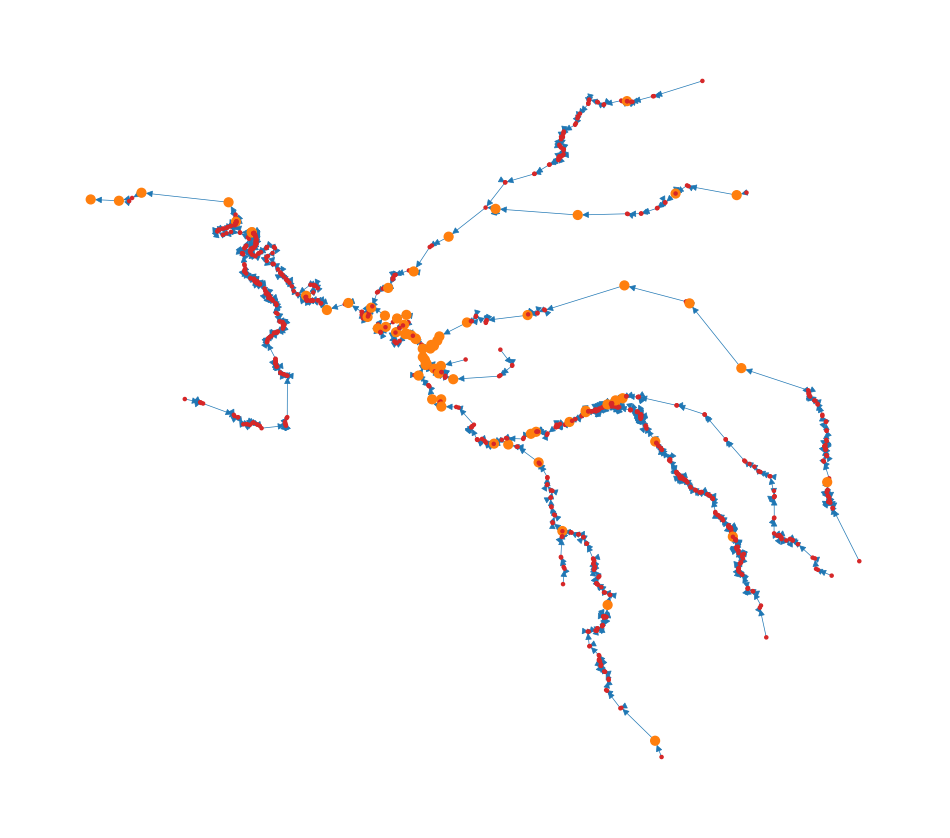

In [ ]:
G_oriented = pickle.load(open('Graphs/G_oriented.pickle', 'rb'))   

pos_contract = {n: n for n in G_oriented.nodes()}

# Couleur différente pour les nœuds correspondant à des stations (sites)
node_colors = [
    "tab:orange" if G_oriented.nodes[n].get("site_id") is not None else "tab:red"
    for n in G_oriented.nodes()
]
node_sizes = [
    40 if G_oriented.nodes[n].get("site_id") is not None else 5
    for n in G_oriented.nodes()
]

fig, ax = plt.subplots(figsize=(12, 12))
nx.draw(
    G_oriented,
    pos=pos_contract,
    ax=ax,
    node_color=node_colors,
    node_size=node_sizes,
    edge_color="tab:blue",
    width=0.5,
    with_labels=False,
)
ax.set_aspect("equal")
plt.show()

**Visualisation du graphe avec cmap qui varie selon la distance des stations (les points) à l'estuaire :**

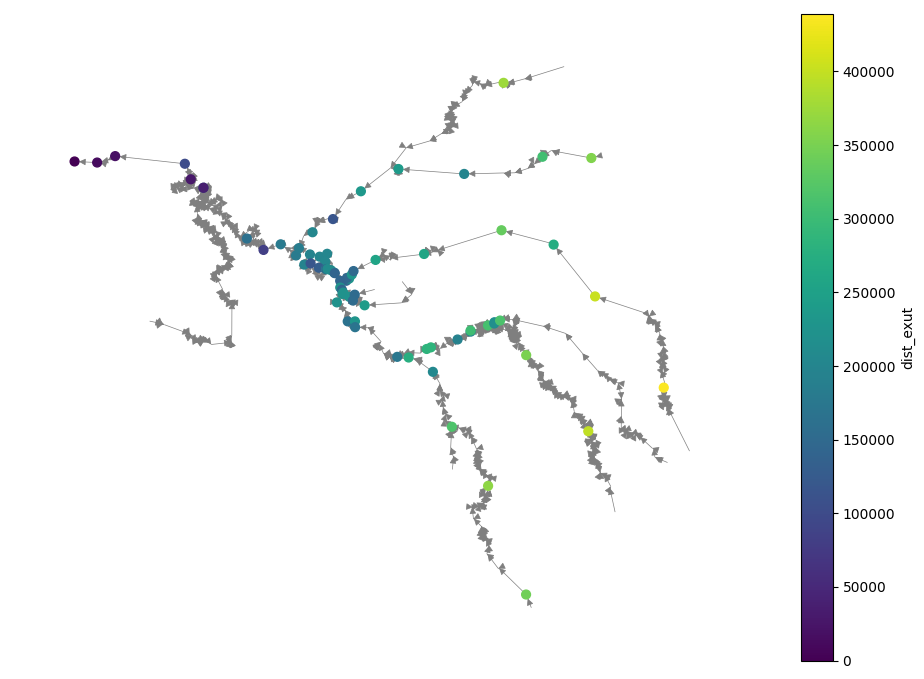

In [ ]:
dist_exut_values = [G_oriented.nodes[n].get("dist_exut",0.) for n in G_oriented.nodes()]

pos_contract = {n: n for n in G_oriented.nodes()}
# Normalisation des valeurs pour la colormap
norm = mcolors.Normalize(vmin=min(dist_exut_values), vmax=max(dist_exut_values))
cmap = cm.viridis  # tu peux changer pour "plasma", "coolwarm", "turbo", etc.

node_colors = [cmap(norm(v)) for v in dist_exut_values]

# Taille toujours différenciée stations / autres
node_sizes = [
    40 if G_oriented.nodes[n].get("site_id") is not None else 0
    for n in G_oriented.nodes()
]

fig, ax = plt.subplots(figsize=(12, 12))
nx.draw(
    G_oriented,
    pos=pos_contract,
    ax=ax,
    node_color=node_colors,
    node_size=node_sizes,
    edge_color="tab:grey",
    width=0.5,
    with_labels=False,
)

# Ajout d'une colorbar pour interpréter les couleurs
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.7)
cbar.set_label("dist_exut")

ax.set_aspect("equal")
plt.show()

# V. Ajout des stations de relevé de débit

On ajoute des nouveaux sites , en plus des stations de relevé de température : les stations de relevé de débit.

# VI. Réduction du graphe

But de la section : réduire les arêtes au strict minimum en gardant la pondération par les distances, ie on a juste un graphe avec des lignes droites entre les stations de relevé (débit et température).

In [ ]:
def reduit(G):
    

# VII. Renommage des zones selon le bras sur lequel elles sont

In [ ]:
def renomme(G):
    

In [5]:
seine = gpd.read_file("Graphs/reseau_seine.gpkg")

seine['TopoOH'].value_counts()

TopoOH
la Seine                     23527
l'Aisne                      22650
l'Aube                       18426
l'Oise                       15766
la Marne                     13761
l'Eure                       12472
l'Yonne                      12210
Bras de la Seine              4947
l'Yerres                      4661
le Réveillon                  2874
le Tholon                     2708
Bras de Marly                  263
Bras de la Monnaie              27
Dérivation de Mericourt         17
Ecluse de la Grande Motte       13
Dérivation de Chatou            12
Name: count, dtype: int64